In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt, log10

Hp = .93
Hs = .1
ws = 3
eps = sqrt((1/Hp**2) - 1)

aa = np.arccosh((1/eps)*sqrt((1/Hs**2)-1))
bb = 1 / np.arccosh(ws)
n = aa * bb

print('n = ', n)

n =  2.223014055460891


alpha =  5.250850271282603
a =  0.5813843102213873  b =  1.156722834637407


<>:27: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_35608\2047939264.py:27: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


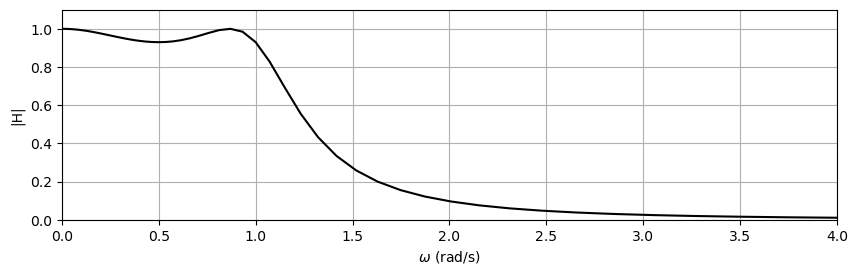

In [15]:
n = 3

alpha = 1/eps + sqrt(1 + 1/eps**2)
print('alpha = ', alpha)

a = 0.5 * (alpha**(1/n) - alpha**(-1/n))
b = 0.5 * (alpha**(1/n) + alpha**(-1/n))
print('a = ', a, ' b = ', b)

theta = (180 - 60) * (pi/180)
d1 = [1, -2*a*cos(theta), (a**2)*cos(theta)**2 + (b**2)*sin(theta)**2]

d2 = [1, a]
K = d1[2] * a

num = [0, 0, K]
den = np.convolve(d1, d2)

system = sig.TransferFunction(num, den)
w, Hmag, Hphase = sig.bode(system)

plt.figure(figsize=(10, 6))
plt.subplot(211)
plt.plot(w,10**(0.05*Hmag),'k')
plt.axis([0,4,0,1.1])
plt.grid(which='both')
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('|H|')
plt.show()